In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt



In [2]:
pd.set_option('display.max_columns', None)  #para ver todas las columnas del df

FASE 1 EXPLORACION INICIAL

Analizo primero el data frame de Flight Activity

In [3]:
df_flight= pd.read_csv("files/customer Flight Activity.csv")
df_flight.head()

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
0,100018,2017,1,3,0,3,1521,152.0,0,0
1,100102,2017,1,10,4,14,2030,203.0,0,0
2,100140,2017,1,6,0,6,1200,120.0,0,0
3,100214,2017,1,0,0,0,0,0.0,0,0
4,100272,2017,1,0,0,0,0,0.0,0,0


In [4]:
df_flight.info()      #miro la info del dataframe 


<class 'pandas.DataFrame'>
RangeIndex: 405624 entries, 0 to 405623
Data columns (total 10 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Loyalty Number               405624 non-null  int64  
 1   Year                         405624 non-null  int64  
 2   Month                        405624 non-null  int64  
 3   Flights Booked               405624 non-null  int64  
 4   Flights with Companions      405624 non-null  int64  
 5   Total Flights                405624 non-null  int64  
 6   Distance                     405624 non-null  int64  
 7   Points Accumulated           405624 non-null  float64
 8   Points Redeemed              405624 non-null  int64  
 9   Dollar Cost Points Redeemed  405624 non-null  int64  
dtypes: float64(1), int64(9)
memory usage: 30.9 MB


In [5]:
df_flight.shape    #miro columnas y filas

(405624, 10)

In [6]:
df_flight.isna().sum()/df_flight.shape[0]*100             #compruebo los nulos

Loyalty Number                 0.0
Year                           0.0
Month                          0.0
Flights Booked                 0.0
Flights with Companions        0.0
Total Flights                  0.0
Distance                       0.0
Points Accumulated             0.0
Points Redeemed                0.0
Dollar Cost Points Redeemed    0.0
dtype: float64

In [7]:
df_flight.duplicated().sum()                   #compruebo los duplicados

np.int64(1864)

In [8]:
df_flight[df_flight.duplicated()]  #observo las filas repetidas

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
42,101902,2017,1,0,0,0,0,0.0,0,0
227,112142,2017,1,0,0,0,0,0.0,0,0
478,126100,2017,1,0,0,0,0,0.0,0,0
567,130331,2017,1,0,0,0,0,0.0,0,0
660,135421,2017,1,0,0,0,0,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...
404668,949628,2018,12,0,0,0,0,0.0,0,0
404884,960050,2018,12,0,0,0,0,0.0,0,0
405111,971370,2018,12,0,0,0,0,0.0,0,0
405410,988392,2018,12,0,0,0,0,0.0,0,0


In [9]:
df_flight.describe().T          # Muestro estadísticas descriptivas de las columnas numéricas

,count,mean,std,min,25%,50%,75%,max
Loyalty Number,405624.0,550037.873084,258935.286969,100018.0,326961.00,550834.0,772194.00,999986.0
Year,405624.0,2017.500000,0.500001,2017.0,2017.00,2017.5,2018.00,2018.0
Month,405624.0,6.500000,3.452057,1.0,3.75,6.5,9.25,12.0
Flights Booked,405624.0,4.115052,5.225518,0.0,0.00,1.0,8.00,21.0
Flights with Companions,405624.0,1.031805,2.076869,0.0,0.00,0.0,1.00,11.0
Total Flights,405624.0,5.146858,6.521227,0.0,0.00,1.0,10.00,32.0
Distance,405624.0,1208.880059,1433.155320,0.0,0.00,488.0,2336.00,6293.0
Points Accumulated,405624.0,123.692721,146.599831,0.0,0.00,50.0,239.00,676.5
Points Redeemed,405624.0,30.696872,125.486049,0.0,0.00,0.0,0.00,876.0
Dollar Cost Points Redeemed,405624.0,2.484503,10.150038,0.0,0.00,0.0,0.00,71.0


Analizo el dataframe de Loyalty History

In [10]:
df_loyalty = pd.read_csv("files/customer Loyalty History.csv")
df_loyalty.head()

,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN
2,429460,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,NaN,Single,Star,3839.75,Standard,2014,7,2018.0,1.0
3,608370,Canada,Ontario,Toronto,P1W 1K4,Male,College,NaN,Single,Star,3839.75,Standard,2013,2,NaN,NaN
4,530508,Canada,Quebec,Hull,J8Y 3Z5,Male,Bachelor,103495.0,Married,Star,3842.79,Standard,2014,10,NaN,NaN


In [11]:
df_loyalty.info()

<class 'pandas.DataFrame'>
RangeIndex: 16737 entries, 0 to 16736
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Loyalty Number      16737 non-null  int64  
 1   Country             16737 non-null  str    
 2   Province            16737 non-null  str    
 3   City                16737 non-null  str    
 4   Postal Code         16737 non-null  str    
 5   Gender              16737 non-null  str    
 6   Education           16737 non-null  str    
 7   Salary              12499 non-null  float64
 8   Marital Status      16737 non-null  str    
 9   Loyalty Card        16737 non-null  str    
 10  CLV                 16737 non-null  float64
 11  Enrollment Type     16737 non-null  str    
 12  Enrollment Year     16737 non-null  int64  
 13  Enrollment Month    16737 non-null  int64  
 14  Cancellation Year   2067 non-null   float64
 15  Cancellation Month  2067 non-null   float64
dtypes: float64(4), 

In [12]:
df_loyalty.shape    #miro columnas y filas

(16737, 16)

In [13]:
df_loyalty.isna().sum()/df_loyalty.shape[0]*100             #compruebo los nulos

Loyalty Number         0.000000
Country                0.000000
Province               0.000000
City                   0.000000
Postal Code            0.000000
Gender                 0.000000
Education              0.000000
Salary                25.321145
Marital Status         0.000000
Loyalty Card           0.000000
CLV                    0.000000
Enrollment Type        0.000000
Enrollment Year        0.000000
Enrollment Month       0.000000
Cancellation Year     87.650117
Cancellation Month    87.650117
dtype: float64

In [14]:
df_loyalty.duplicated().sum()                   #compruebo duplicados

np.int64(0)

In [15]:
df_loyalty.describe().T          # Muestra estadísticas descriptivas de las columnas numéricas 

,count,mean,std,min,25%,50%,75%,max
Loyalty Number,16737.0,549735.880445,258912.132453,100018.00,326603.00,550434.00,772019.00,999986.00
Salary,12499.0,79245.609409,35008.297285,-58486.00,59246.50,73455.00,88517.50,407228.00
CLV,16737.0,7988.896536,6860.982280,1898.01,3980.84,5780.18,8940.58,83325.38
Enrollment Year,16737.0,2015.253211,1.979111,2012.00,2014.00,2015.00,2017.00,2018.00
Enrollment Month,16737.0,6.669116,3.398958,1.00,4.00,7.00,10.00,12.00
Cancellation Year,2067.0,2016.503145,1.380743,2013.00,2016.00,2017.00,2018.00,2018.00
Cancellation Month,2067.0,6.962748,3.455297,1.00,4.00,7.00,10.00,12.00


Uno los 2 DataFrame

In [16]:
df_flight.merge(df_loyalty, how='left', on="Loyalty Number")      #usa sólo las claves del DataFrame izquierdo

df_final= df_flight.merge(df_loyalty, how='left', on="Loyalty Number")  

In [17]:
df_final


,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
0,100018,2017,1,3,0,3,1521,152.0,0,0,Canada,Alberta,Edmonton,T9G 1W3,Female,Bachelor,92552.0,Married,Aurora,7919.20,Standard,2016,8,NaN,NaN
1,100102,2017,1,10,4,14,2030,203.0,0,0,Canada,Ontario,Toronto,M1R 4K3,Male,College,NaN,Single,Nova,2887.74,Standard,2013,3,NaN,NaN
2,100140,2017,1,6,0,6,1200,120.0,0,0,Canada,British Columbia,Dawson Creek,U5I 4F1,Female,College,NaN,Divorced,Nova,2838.07,Standard,2016,7,NaN,NaN
3,100214,2017,1,0,0,0,0,0.0,0,0,Canada,British Columbia,Vancouver,V5R 1W3,Male,Bachelor,63253.0,Married,Star,4170.57,Standard,2015,8,NaN,NaN
4,100272,2017,1,0,0,0,0,0.0,0,0,Canada,Ontario,Toronto,P1L 8X8,Female,Bachelor,91163.0,Divorced,Star,6622.05,Standard,2014,1,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
405619,999902,2018,12,0,0,0,0,0.0,0,0,Canada,Ontario,Toronto,M1R 4K3,Male,College,NaN,Married,Aurora,7290.07,Standard,2014,5,NaN,NaN
405620,999911,2018,12,0,0,0,0,0.0,0,0,Canada,Newfoundland,St. John's,A1C 6H9,Male,Doctor,217943.0,Single,Nova,8564.77,Standard,2012,8,NaN,NaN
405621,999940,2018,12,3,0,3,1233,123.0,0,0,Canada,Quebec,Quebec City,G1B 3L5,Female,Bachelor,47670.0,Married,Nova,20266.50,Standard,2017,7,NaN,NaN
405622,999982,2018,12,0,0,0,0,0.0,0,0,Canada,British Columbia,Victoria,V10 6T5,Male,College,NaN,Married,Star,2631.56,Standard,2018,7,NaN,NaN


FASE 2 LIMPIEZA DE DATOS

Detecto que tengo valores nulos en el salario y lo comparo con la educación ya que entiendo que tienen relacion. A si mismo me doy cuenta que en el salario tengo valores negativos y al hacer esa comparación con Educacion me doy cuenta que ha podido ser un error por lo cual voy a pasarlos a valores positivos

In [18]:
df_final.groupby("Salary")["Education"].value_counts()

Salary     Education           
-58486.0   Bachelor                24
-57297.0   Bachelor                24
-49830.0   High School or Below    24
-49001.0   Bachelor                24
-47310.0   Bachelor                24
                                   ..
 362833.0  Doctor                  24
 363189.0  Doctor                  24
 381124.0  Doctor                  24
 397919.0  Doctor                  24
 407228.0  Doctor                  24
Name: count, Length: 5927, dtype: int64

In [19]:
df_final.head()

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month
0,100018,2017,1,3,0,3,1521,152.0,0,0,Canada,Alberta,Edmonton,T9G 1W3,Female,Bachelor,92552.0,Married,Aurora,7919.20,Standard,2016,8,NaN,NaN
1,100102,2017,1,10,4,14,2030,203.0,0,0,Canada,Ontario,Toronto,M1R 4K3,Male,College,NaN,Single,Nova,2887.74,Standard,2013,3,NaN,NaN
2,100140,2017,1,6,0,6,1200,120.0,0,0,Canada,British Columbia,Dawson Creek,U5I 4F1,Female,College,NaN,Divorced,Nova,2838.07,Standard,2016,7,NaN,NaN
3,100214,2017,1,0,0,0,0,0.0,0,0,Canada,British Columbia,Vancouver,V5R 1W3,Male,Bachelor,63253.0,Married,Star,4170.57,Standard,2015,8,NaN,NaN
4,100272,2017,1,0,0,0,0,0.0,0,0,Canada,Ontario,Toronto,P1L 8X8,Female,Bachelor,91163.0,Divorced,Star,6622.05,Standard,2014,1,NaN,NaN


<Axes: xlabel='Salary'>

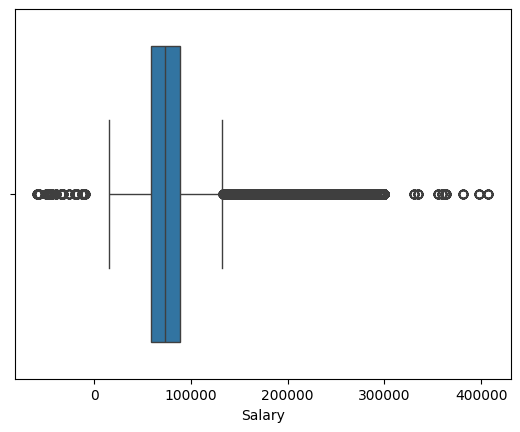

In [20]:
sns.boxplot(data= df_final, x="Salary")    #compruebo con la gráfica que efectivamente los valores negativos del salario perfectamente pueden cambiarse a positivo

<Axes: xlabel='Education', ylabel='Salary'>

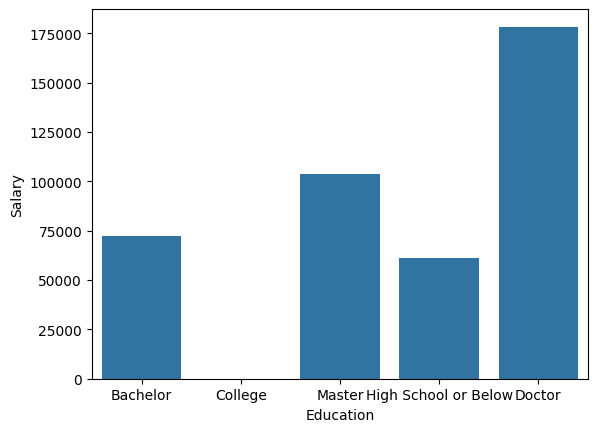

In [21]:
sns.barplot(data= df_final, x="Education", y="Salary", errorbar=None)         #comparo la educacion con el salario para ver el tipo de relacion y me afirma  los datos nulos

In [22]:
df_final["Salary"] = df_final["Salary"].abs()                  #paso a positivo los valores negativos que habia en la columna salario

In [23]:
df_final.describe().T                              #compruebo que se ha realizado el cambio y en el minimo ya no tengo ningun valor negativo

,count,mean,std,min,25%,50%,75%,max
Loyalty Number,405624.0,550037.873084,258935.286969,100018.00,326961.00,550834.00,772194.00,999986.00
Year,405624.0,2017.500000,0.500001,2017.00,2017.00,2017.50,2018.00,2018.00
Month,405624.0,6.500000,3.452057,1.00,3.75,6.50,9.25,12.00
Flights Booked,405624.0,4.115052,5.225518,0.00,0.00,1.00,8.00,21.00
Flights with Companions,405624.0,1.031805,2.076869,0.00,0.00,0.00,1.00,11.00
Total Flights,405624.0,5.146858,6.521227,0.00,0.00,1.00,10.00,32.00
Distance,405624.0,1208.880059,1433.155320,0.00,0.00,488.00,2336.00,6293.00
Points Accumulated,405624.0,123.692721,146.599831,0.00,0.00,50.00,239.00,676.50
Points Redeemed,405624.0,30.696872,125.486049,0.00,0.00,0.00,0.00,876.00
Dollar Cost Points Redeemed,405624.0,2.484503,10.150038,0.00,0.00,0.00,0.00,71.00


In [24]:
df_final['Salary'].isnull().sum()                  

np.int64(102672)

In [25]:
df_final[df_final['Salary'].isnull()][['Salary', 'Education']]                     #compruebo en que categoria estan esos nulos

,Salary,Education
1,NaN,College
2,NaN,College
17,NaN,College
20,NaN,College
21,NaN,College
...,...,...
405611,NaN,College
405613,NaN,College
405616,NaN,College
405619,NaN,College


In [26]:
df_final.groupby("Education")["Salary"].apply(lambda x: x.isnull().mean() * 100)            #compruebo en que categoria estan esos nulos

#con lambda lo que hago es decir que me aplique la formula insull si hay dato marca true o viceversa y añade o y 1 a true/false y me da la cantidad 

Education
Bachelor                  0.0
College                 100.0
Doctor                    0.0
High School or Below      0.0
Master                    0.0
Name: Salary, dtype: float64

In [27]:
df_final["Salary"] = df_final["Salary"].fillna(df_final["Salary"].median()) #los he imputado usando la mediana debido a la presencia de valores extremos.

In [28]:
df_final['Salary'].isnull().sum()    #compruebo que se han realizado los cambios

np.int64(0)

Compruebo que tanto la columna cancellation year y cancellation month tienen exactamente los mismos nulos , procedo a duplicar las columnas y luego las elimino ya que para este ejercicio no son redundantes

In [29]:
df_final["Cancellation Year"].isnull().sum()     

np.int64(355560)

In [30]:
df_final["Cancellation Month"].isnull().sum()

np.int64(355560)

In [31]:
print(df_final["Cancellation Year"])

0        NaN
1        NaN
2        NaN
3        NaN
4        NaN
          ..
405619   NaN
405620   NaN
405621   NaN
405622   NaN
405623   NaN
Name: Cancellation Year, Length: 405624, dtype: float64


In [32]:
df_final["clientes activos mes"] = df_final["Cancellation Month"].fillna('activo')  #duplico columas para gestionar los nulos y pasarlos a activo

In [33]:
df_final["clientes activos año"] = df_final[ "Cancellation Year"].fillna('activo')


In [34]:
df_final.head()                  #compruebo cambios

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month,clientes activos mes,clientes activos año
0,100018,2017,1,3,0,3,1521,152.0,0,0,Canada,Alberta,Edmonton,T9G 1W3,Female,Bachelor,92552.0,Married,Aurora,7919.20,Standard,2016,8,NaN,NaN,activo,activo
1,100102,2017,1,10,4,14,2030,203.0,0,0,Canada,Ontario,Toronto,M1R 4K3,Male,College,73479.0,Single,Nova,2887.74,Standard,2013,3,NaN,NaN,activo,activo
2,100140,2017,1,6,0,6,1200,120.0,0,0,Canada,British Columbia,Dawson Creek,U5I 4F1,Female,College,73479.0,Divorced,Nova,2838.07,Standard,2016,7,NaN,NaN,activo,activo
3,100214,2017,1,0,0,0,0,0.0,0,0,Canada,British Columbia,Vancouver,V5R 1W3,Male,Bachelor,63253.0,Married,Star,4170.57,Standard,2015,8,NaN,NaN,activo,activo
4,100272,2017,1,0,0,0,0,0.0,0,0,Canada,Ontario,Toronto,P1L 8X8,Female,Bachelor,91163.0,Divorced,Star,6622.05,Standard,2014,1,NaN,NaN,activo,activo


In [35]:
df_final.drop(["Cancellation Year", "Cancellation Month"], axis=1, inplace=True)            #Elimino las columnas ya que las habia duplicado antes cambiando los valores nulos

In [36]:
df_final.head()   #compruebo que se han eliminado

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,clientes activos mes,clientes activos año
0,100018,2017,1,3,0,3,1521,152.0,0,0,Canada,Alberta,Edmonton,T9G 1W3,Female,Bachelor,92552.0,Married,Aurora,7919.20,Standard,2016,8,activo,activo
1,100102,2017,1,10,4,14,2030,203.0,0,0,Canada,Ontario,Toronto,M1R 4K3,Male,College,73479.0,Single,Nova,2887.74,Standard,2013,3,activo,activo
2,100140,2017,1,6,0,6,1200,120.0,0,0,Canada,British Columbia,Dawson Creek,U5I 4F1,Female,College,73479.0,Divorced,Nova,2838.07,Standard,2016,7,activo,activo
3,100214,2017,1,0,0,0,0,0.0,0,0,Canada,British Columbia,Vancouver,V5R 1W3,Male,Bachelor,63253.0,Married,Star,4170.57,Standard,2015,8,activo,activo
4,100272,2017,1,0,0,0,0,0.0,0,0,Canada,Ontario,Toronto,P1L 8X8,Female,Bachelor,91163.0,Divorced,Star,6622.05,Standard,2014,1,activo,activo


In [37]:
df_final.isna().sum()/df_loyalty.shape[0]*100   #compruebo que efectivamente no hay nulos

Loyalty Number                 0.0
Year                           0.0
Month                          0.0
Flights Booked                 0.0
Flights with Companions        0.0
Total Flights                  0.0
Distance                       0.0
Points Accumulated             0.0
Points Redeemed                0.0
Dollar Cost Points Redeemed    0.0
Country                        0.0
Province                       0.0
City                           0.0
Postal Code                    0.0
Gender                         0.0
Education                      0.0
Salary                         0.0
Marital Status                 0.0
Loyalty Card                   0.0
CLV                            0.0
Enrollment Type                0.0
Enrollment Year                0.0
Enrollment Month               0.0
clientes activos mes           0.0
clientes activos año           0.0
dtype: float64

paso a borrar los duplicados

In [38]:
df_final.duplicated().sum()               #miro las filas dulicadas

np.int64(1864)

In [39]:
df_final[df_final.duplicated()]

,Loyalty Number,Year,Month,Flights Booked,Flights with Companions,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,clientes activos mes,clientes activos año
42,101902,2017,1,0,0,0,0,0.0,0,0,Canada,Ontario,London,M5B 3E4,Female,College,73479.0,Married,Aurora,6265.34,Standard,2017,1,activo,activo
227,112142,2017,1,0,0,0,0,0.0,0,0,Canada,Ontario,Thunder Bay,K8T 5M5,Male,Bachelor,93073.0,Single,Aurora,16272.74,Standard,2015,7,activo,activo
478,126100,2017,1,0,0,0,0,0.0,0,0,Canada,New Brunswick,Fredericton,E3B 2H2,Female,Master,121261.0,Divorced,Nova,17790.41,Standard,2013,11,7.0,2014.0
567,130331,2017,1,0,0,0,0,0.0,0,0,Canada,Nova Scotia,Halifax,B3J 9S2,Female,Bachelor,79207.0,Divorced,Nova,2862.73,Standard,2016,12,activo,activo
660,135421,2017,1,0,0,0,0,0.0,0,0,Canada,Nova Scotia,Halifax,B3C 2M8,Female,Bachelor,91156.0,Married,Aurora,17441.64,Standard,2017,1,activo,activo
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
404668,949628,2018,12,0,0,0,0,0.0,0,0,Canada,Saskatchewan,Regina,S6J 3G0,Female,College,73479.0,Married,Star,2563.58,Standard,2012,7,activo,activo
404884,960050,2018,12,0,0,0,0,0.0,0,0,Canada,Ontario,Thunder Bay,K8T 5M5,Female,Bachelor,103151.0,Single,Aurora,8622.84,Standard,2015,12,activo,activo
405111,971370,2018,12,0,0,0,0,0.0,0,0,Canada,Ontario,Toronto,P2T 6G3,Male,Bachelor,63791.0,Married,Aurora,5261.04,Standard,2012,7,activo,activo
405410,988392,2018,12,0,0,0,0,0.0,0,0,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,73479.0,Single,Aurora,9022.08,Standard,2012,5,activo,activo


In [40]:
df_final=df_final.drop_duplicates(keep="first")          #borro los datos duplicados y conservo la primera aparicion para evistar sesgos en el analisis

In [41]:
df_final[df_final.duplicated()].value_counts().sum()       

#confirmo que se han eliminado esos duplicados filtro los duplicados, con value que me cuenta las filas duplicadas y sums que las suma

np.int64(0)

FASE 2 ANALISIS ESTADISTICO

#variables numericas

In [42]:
df_final[["Flights Booked", "Distance", "Points Accumulated", "Salary", "CLV"]].describe().T   #Saco las estadisticas descriptivas de las numericas mas relevantes

,count,mean,std,min,25%,50%,75%,max
Flights Booked,403760.0,4.134050,5.230064,0.00,0.00,1.00,8.00,21.00
Distance,403760.0,1214.460979,1434.098521,0.00,0.00,525.00,2342.00,6293.00
Points Accumulated,403760.0,124.263761,146.696179,0.00,0.00,53.00,240.00,676.50
Salary,403760.0,77879.284748,30117.567539,9081.00,63901.00,73479.00,82940.00,407228.00
CLV,403760.0,7990.864857,6863.317160,1898.01,3981.78,5776.34,8937.12,83325.38


Segun puedo comprobar en la estadísta descriptiva de Flights Booked El promedio es de 4.13, sin embargo la mediana es solo 1, lo que me da a entender que vuelan muy poco
En el salario: El sueldo típico ronda los 73479 y esta muy  cerca de la media. Mas o menos tienen el mismo poder adquisitivo quitando algun pico en el 75% y max
CLV:  me hace ver a primera vista que hay mas clientes que aportan valor a la empresa

Compruebo  los valores atípicos de las variables numericas

<Axes: xlabel='Salary'>

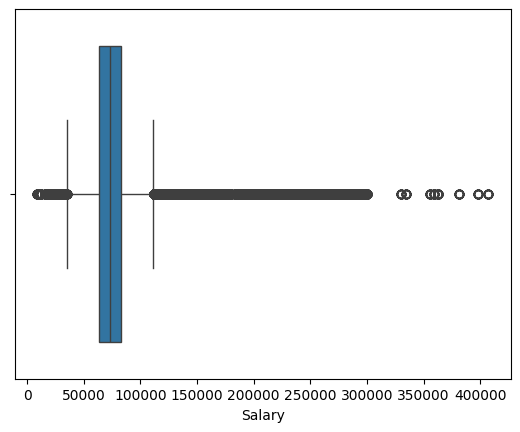

In [43]:
sns.boxplot(data= df_final, x="Salary") 

<Axes: xlabel='CLV'>

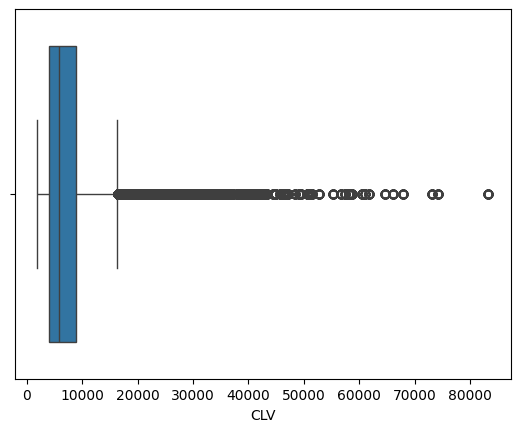

In [44]:
sns.boxplot(data= df_final, x="CLV") 

<Axes: xlabel='Distance'>

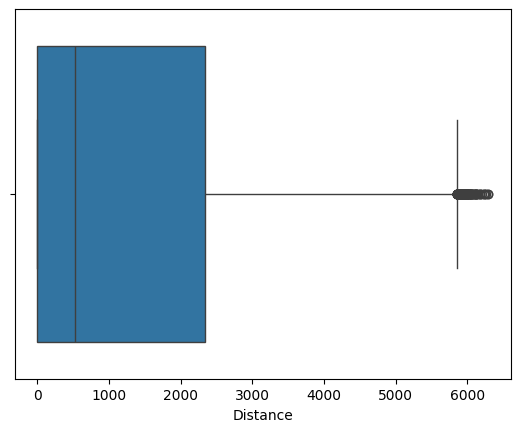

In [45]:
sns.boxplot(data= df_final, x="Distance")

<Axes: xlabel='Flights Booked'>

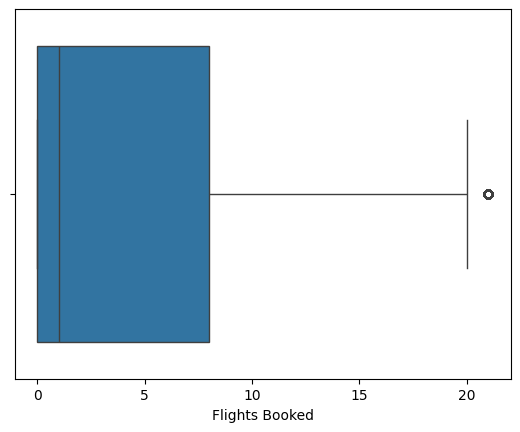

In [46]:
sns.boxplot(data= df_final, x="Flights Booked")

comparando el maximo con el 75% hay clientes con ingresos que se salen de la normalidad, lo mismo podemos decir del CLV. Se puede comprobar que los vuelos que mas se realizan son de mayor distancia y por norma general los viajeros reservan muy pocos vuelos pero hay una pequeña cantidad de clientes que vuela mucho por ello sube el 75% 

In [47]:
df_corr_reducido = df_final[["Salary", "Flights Booked", "Points Accumulated","Distance", "CLV"]].corr()

df_corr_reducido

,Salary,Flights Booked,Points Accumulated,Distance,CLV
Salary,1.000000,0.004754,0.006638,0.006739,-0.016365
Flights Booked,0.004754,1.000000,0.759547,0.766748,-0.002847
Points Accumulated,0.006638,0.759547,1.000000,0.994546,-0.000942
Distance,0.006739,0.766748,0.994546,1.000000,-0.004132
CLV,-0.016365,-0.002847,-0.000942,-0.004132,1.000000


<Axes: >

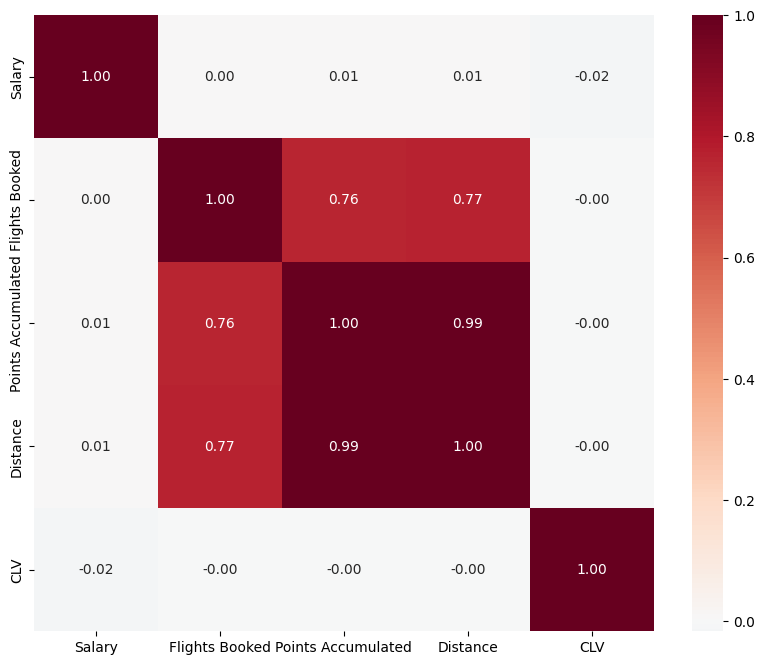

In [48]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_corr_reducido, 
            annot=True,       # Muestra los números dentro de los cuadros
            cmap='RdBu_r',    
            fmt=".2f",        # Redondea a 2 decimales
            center=0)  

con esta correlacion podemos ver que hay una cierta relacion entre los vuelos, la distancia y los puntos acumulados

In [52]:
df_final.describe(exclude=np.number)

,Country,Province,City,Postal Code,Gender,Education,Marital Status,Loyalty Card,Enrollment Type,clientes activos mes,clientes activos año
count,403760,403760,403760,403760,403760,403760,403760,403760,403760,403760,403760
unique,1,11,29,55,2,5,3,3,2,13,7
top,Canada,Ontario,Toronto,V6E 3D9,Female,Bachelor,Married,Star,Standard,activo,activo
freq,403760,130258,80775,21944,202757,252567,234845,183745,380419,354110,354110


In [50]:
#Se exporta el dataset limpio y seguir con la fase de visualizacion
df_final.to_csv("df_clean.csv",index=False)